[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


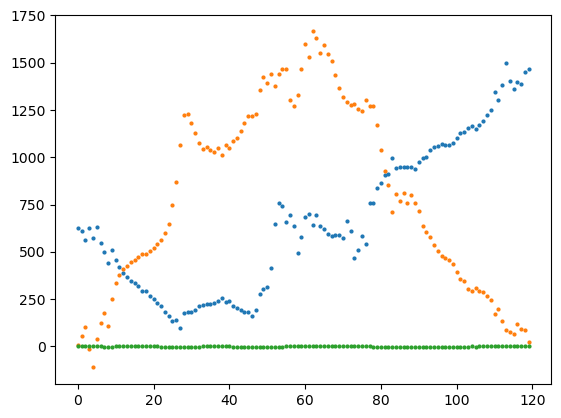

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import taichi as ti
from utils import get_sofa, monotonicly_interpolate
from PIL import Image

ti.init(arch=ti.gpu)

path, file_name = '../trajectory/九顿天窗_1/', 'sofa_5083.npy'

# 载入轨迹数据
xs, ys, rotations = np.load(path + file_name)

# 数据点
plt.plot(xs, 'o', markersize=2)
plt.plot(ys, 'o', markersize=2)
plt.plot(rotations, 'o', markersize=2)

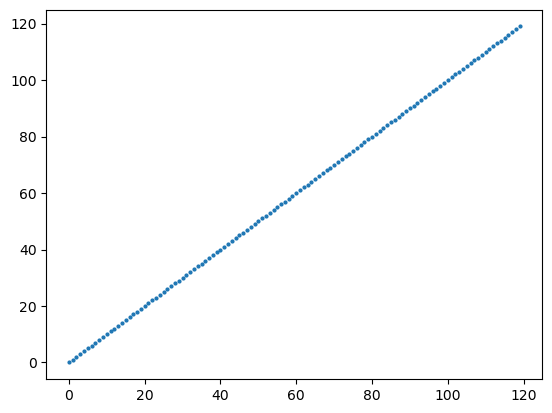

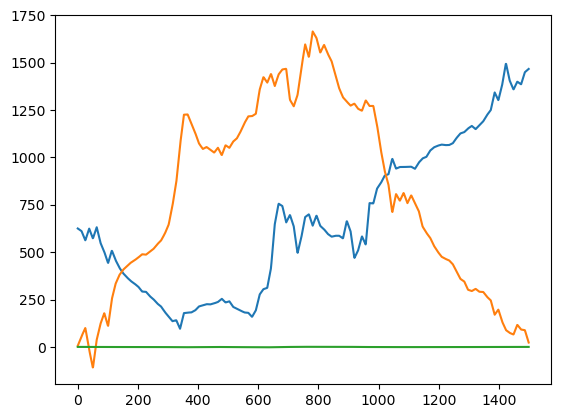

In [2]:
def key_function(xs, ys, rotations):  # 要求这个函数单调递增来重新采样
    return np.arange(len(xs))  # 不重新排序

keys = key_function(xs, ys, rotations)
plt.plot(keys, 'o', markersize=2)
plt.show()

xs_monotonic, ys_monotonic, rotations_monotonic = monotonicly_interpolate(
    keys,
    np.array([xs, ys, rotations]).T,
    1500,
    key_min=keys[0],
    key_max=keys[-1]
).T
plt.plot(xs_monotonic)
plt.plot(ys_monotonic)
plt.plot(rotations_monotonic)

In [3]:
wall_image = Image.open('../input_images/九顿天窗_平滑.png')

wall_numpy = np.array(wall_image).T > 0  # 读取图片并转换为布尔数组
assert len(wall_numpy.shape) == 2, "Image must be grayscale"

wall_taichi = ti.field(dtype=ti.i8, shape=wall_numpy.shape)
wall_taichi.from_numpy(wall_numpy.astype(np.int8))

Area = 149578


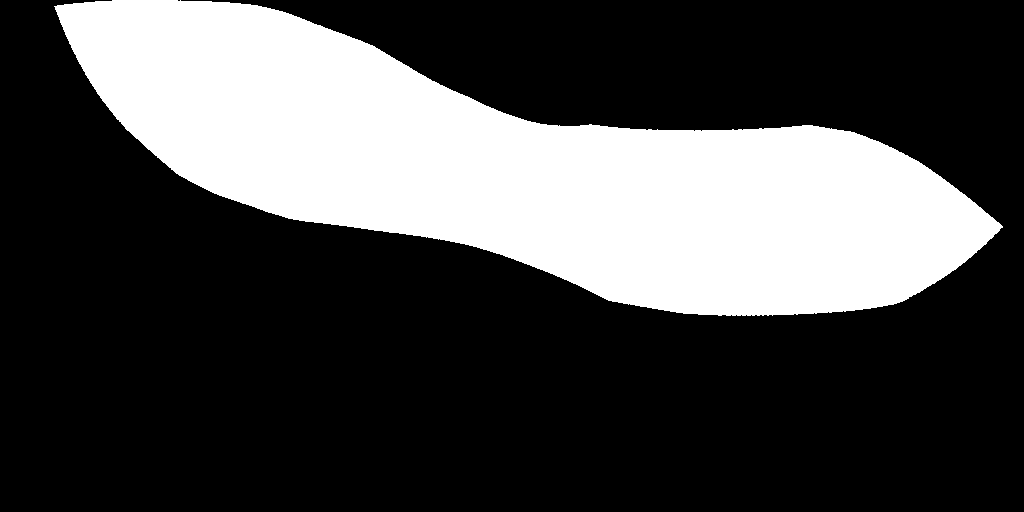

In [4]:
sofa_w = 400   # 求解域的尺寸
sofa_h = 200   # 求解域的尺寸
@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    x2 = max(0, x2)
    y2 = max(0, y2)
    x2 = min(wall_taichi.shape[0] - 1, x2)
    y2 = min(wall_taichi.shape[1] - 1, y2)
    return wall_taichi[int(x2), int(y2)]

sofa, survive_mask = get_sofa(is_forbidden, xs, ys, rotations, resolution=1024, sofa_w=sofa_w, sofa_h=sofa_h, trajectory_upsampling=101, return_hitting_time=True)
# sofa, survive_mask = get_sofa(
#     is_forbidden, xs_monotonic, ys_monotonic, rotations_monotonic, resolution=1500,
#     sofa_w=sofa_w, sofa_h=sofa_h,
#     trajectory_upsampling=1, return_hitting_time=True)
print(f'Area = {np.sum(sofa)}')  # 计算面积（像素）

image = Image.fromarray(np.array(sofa.T[::-1] * 255, dtype=np.uint8))
image

[0, 58, 125, 202, 290, 392, 508, 642, 796, 972, 1175, 1408, 1677, 1985, 2339, 2746, 3214, 3753, 4371, 5083]


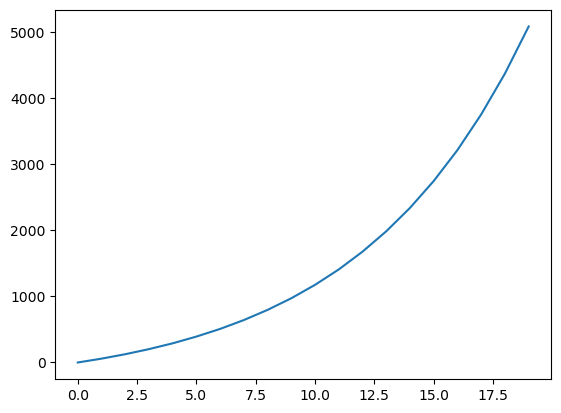

In [21]:
# 适配九顿天窗
def id_function(i):
    return int(382.75 * (1.15 ** i - 1) - -1 * i)

print([id_function(i) for i in range(20)])
plt.plot([id_function(i) for i in range(20)])

In [26]:
58 * 83

4814

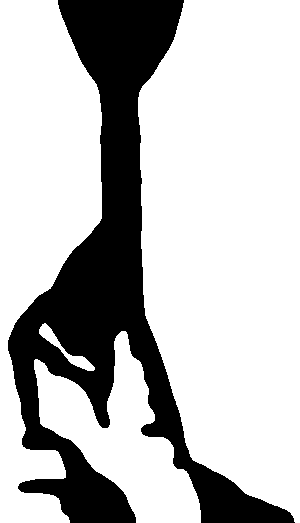

In [6]:
from utils import test_forbidden_function

image = test_forbidden_function(
    is_forbidden,
    0, 1834, 0, 3200, [300, round(300 * 3200 / 1834)],
    # wall_normal=[0, 0.05]
)
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [32]:
# 渲染若干个沙发依次经过拐角的动画

from PIL import ImageDraw, ImageFont
from tqdm.notebook import tqdm
import os
from scipy.ndimage import gaussian_filter1d
from utils import test_forbidden_function, get_area
from animation_tools import draw_sofa, generate_animated_sofa, dilate

resolution = (2560, 1440)
scale = 0.48  # 单位1对应多少像素
origin = (500, 1350)  # 适配九顿天窗
duration = 120
time_scale = 1.0

output_path = '../rendering_results/九顿天窗/'

# 根据墙函数渲染背景
# background_upsampling = 1
# print(-origin[0] / scale, (resolution[0] - origin[0]) / scale, -(resolution[1] - origin[1]) / scale, origin[1] / scale)
# background = test_forbidden_function(
#     is_forbidden,
#     -origin[0] / scale, (resolution[0] - origin[0]) / scale,
#     -(resolution[1] - origin[1]) / scale, origin[1] / scale,
#     [e * background_upsampling for e in resolution],
#     wall_normal=[0, 0]
# )
# background = background.T[::-1]
# background_dilate = 1 - dilate(1 - background, radius=4 * background_upsampling)
# background = np.array((255 - background * 75) * (1 - np.logical_xor(background, background_dilate)), dtype=np.uint8)
# background = np.stack([background, background, background], axis=-1)
# background = Image.fromarray(background)
# background = background.resize((background.width // background_upsampling, background.height // background_upsampling))

# 载入图片作为背景
background = Image.open('../input_images/九顿天窗_渲染.png')
background = background.transpose(Image.FLIP_TOP_BOTTOM)  # 垂直翻转图像

# 如果输出路径不存在，构建路径
if not os.path.exists(output_path):
    os.makedirs(output_path)

active_sofas = {}
emit_every_frames = int(90 * time_scale)
text_row_1 = ''
text_row_2 = ''
text_to_update = []
for frame in tqdm(range(emit_every_frames * 19 + int((duration + 140) * time_scale))):
# for frame in tqdm(range(100)):
    # 加入新的沙发
    if frame % emit_every_frames == 0:
        id = id_function(frame // emit_every_frames)
        if os.path.exists(f'{path}sofa_{id}.npy'):

            def data_post_process(xs, ys, rotations):  # 平滑化动画路径
                xs_blured = gaussian_filter1d(xs, sigma=len(xs) / 20, mode='nearest')  # 20
                ys_blured = gaussian_filter1d(ys, sigma=len(xs) / 20, mode='nearest')
                rotations_blured = gaussian_filter1d(rotations, sigma=len(xs) / 20, mode='nearest')
                return xs_blured, ys_blured, rotations_blured

            new_sofa = generate_animated_sofa(
                is_forbidden,
                f'{path}sofa_',
                id,
                frame + int(duration * time_scale),  # 适配大多数动画
                int(duration * time_scale),
                int(scale * sofa_w * 2),
                sofa_w=sofa_w,
                sofa_h=sofa_h,
                key_function=key_function,  # （适用于双拐角）
                id_factor=83,  # 83
                draw_text=False,  # 不绘制文本
                # text_size_factor=0.06,  # 文字尺寸（单拐角）
                text_size_factor=0.045,  # 文字尺寸（双拐角）
                # text_color=(0, 0, 0),  # 黑色文本（默认是白色）
                # trajectory_updampling=10
                # data_post_process=data_post_process,
                # area_factor=(1 / r2) ** 2
                pattern_id=id + 12  # 改变这个值可以改变图案
            )
            active_sofas[str(frame // emit_every_frames)] = new_sofa
            xs, ys, rotations = np.load(f'{path}sofa_{id}.npy')
            area = get_area(is_forbidden, xs, ys, rotations, resolution=1024, sofa_w=sofa_w, sofa_h=sofa_h, trajectory_upsampling=101) * (21 / 219) ** 2
            text_to_update.append({'start_time': new_sofa['start_time'], 'texts': [f'#{id * 83}', f'S = {area:.2f}m²']})  # 之后在指定的时刻更新文本

    rendering_target = background.copy()

    # 绘制沙发
    for key in list(active_sofas.keys()):
        # 当沙发超出时间范围时删除它们
        # if frame - active_sofas[key]['start_time'] >= int(160 * time_scale):  # 适配大多数动画 140
            # del active_sofas[key]  # 删除已经移出显示区域的沙发
            # continue
        draw_sofa(
            rendering_target, origin, scale, active_sofas[key]['image'], active_sofas[key]['xs'], active_sofas[key]['ys'], active_sofas[key]['rotations'], frame - active_sofas[key]['start_time'],
            sofa_h=sofa_h,
            v_estimate_point_num=10,  # 用开头或末尾的10个数据点估计用于延拓的速度
            stop_after_process=True
        )

    rendering_target = rendering_target.transpose(Image.FLIP_TOP_BOTTOM)  # 垂直翻转图像

    # 绘制文本
    if len(text_to_update) > 0:
        if frame >= text_to_update[0]['start_time']:
            text_row_1 = text_to_update[0]['texts'][0]
            text_row_2 = text_to_update[0]['texts'][1]
            del text_to_update[0]
    draw = ImageDraw.Draw(rendering_target)
    font = ImageFont.truetype("simhei.ttf", 60)
    draw.text((80, 130), text_row_1, fill=(255, 255, 255), font=font)
    font = ImageFont.truetype("segoeui.ttf", 40)
    draw.text((80, 210), text_row_2, fill=(255, 255, 255), font=font)

    # rendering_target.save(f"{output_path}{frame}.png", compress_level=6)
    rendering_target.save(f"{output_path}{frame}.jpg", quality=97)

    # if frame > 200:
    #     break
    # break
# rendering_target

  0%|          | 0/1970 [00:00<?, ?it/s]

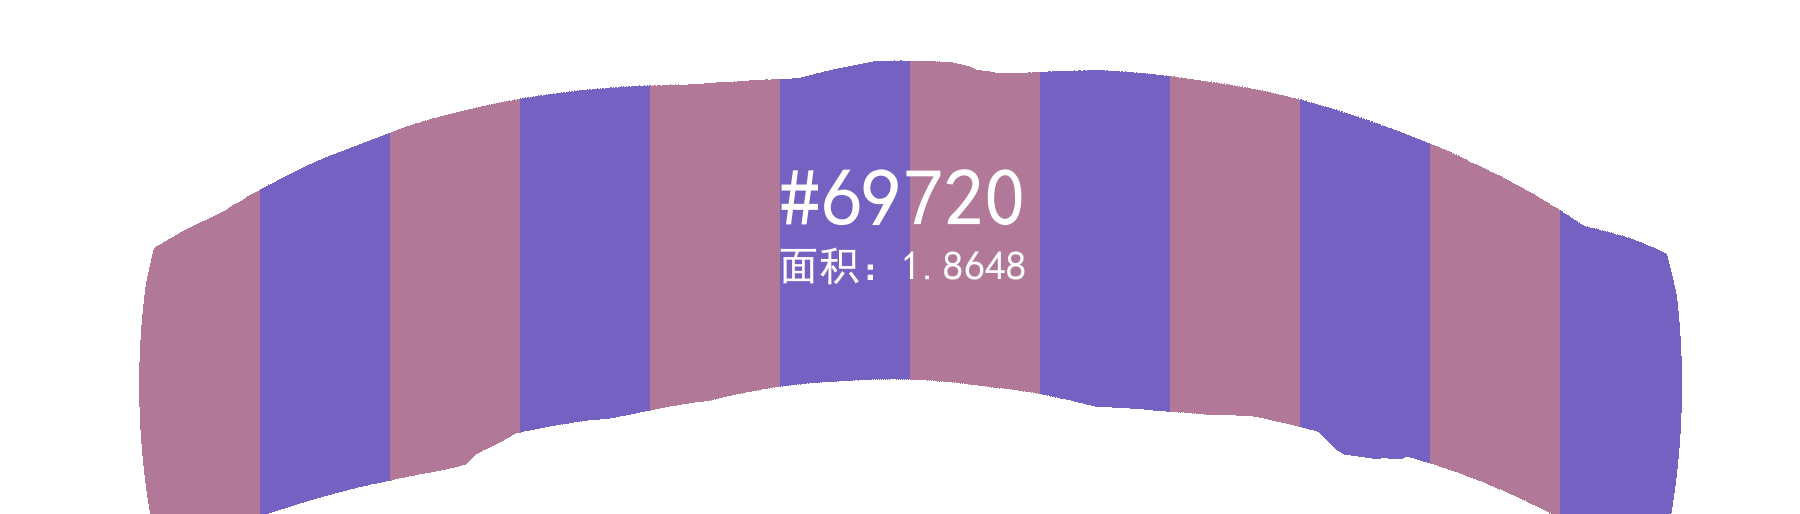

In [ ]:
from animation_tools import  generate_animated_sofa

generate_animated_sofa(
    is_forbidden,
    f'{path}sofa_',
    840,
    0,
    90,
    1800,
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    key_function=key_function,  # （适用于双拐角）
    pattern_id=119603 // 83 + 45,
    id_factor=83,  # 83
    # draw_text=False,
    # text_size_factor=0.06,  # 文字尺寸（单拐角）
    text_size_factor=0.045,  # 文字尺寸（双拐角）
    # text_color=(0, 0, 0),  # 黑色文本
    # trajectory_updampling=10
    # area_factor=(1 / 7) ** 2
)['image']

In [ ]:
import winsound

winsound.MessageBeep()  # 播放系统提示音